In [ ]:
%matplotlib widget
import numpy as np # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
from astropy.constants import G, c # type: ignore
from astropy.cosmology import Planck18 as cosmo # type: ignore
import astropy.units as u # type: ignore

In [26]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\Skyserver_SQL6_22_2025 3_21_26 PM.csv", skiprows=1)
print(df.columns)
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',
    'ra': 'first',
    'dec': 'first',
    'proj_sep': 'first',
    'rmag': 'first'
}).reset_index()

Index(['objid', 'ra', 'dec', 'photoz', 'photozerr', 'specz', 'speczerr',
       'proj_sep', 'umag', 'umagerr', 'gmag', 'gmagerr', 'rmag', 'rmagerr',
       'obj_type'],
      dtype='object')


In [30]:
mean_z = averaged_df['specz'].mean()
std_z = averaged_df['specz'].std()
z_min = mean_z - 3 * std_z
z_max = mean_z + 3 * std_z

filtered_df = averaged_df[(averaged_df['specz'] >= z_min) & (averaged_df['specz'] <= z_max)]


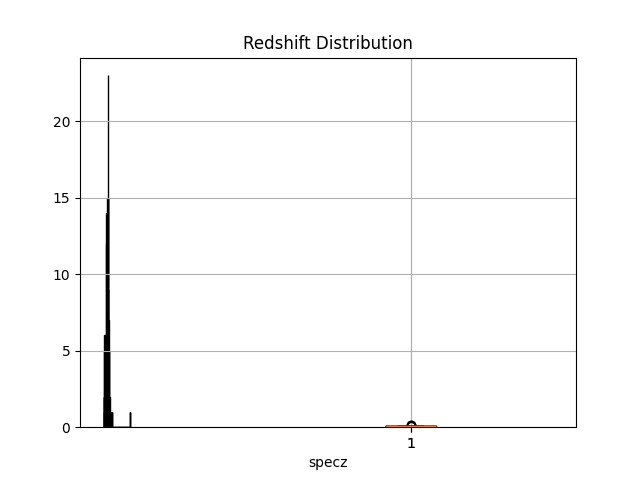

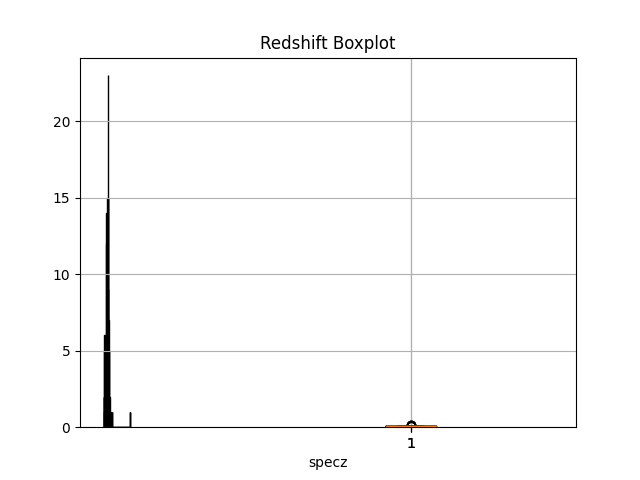

In [35]:
plt.hist(averaged_df['specz'], bins=90, color='skyblue', edgecolor='black')
plt.title("Redshift Distribution")
plt.xlabel("specz")
plt.grid()
plt.show()

plt.boxplot(averaged_df['specz'])
plt.title("Redshift Boxplot")
plt.show()


In [37]:
z_bar = filtered_df['specz'].mean()
filtered_df['velocity'] = c.value * ((filtered_df['specz'] - z_bar) / (1 + z_bar))  # in m/s

C:\Users\Dell\AppData\Local\Temp\ipykernel_32080\3385898704.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['velocity'] = c.value * ((filtered_df['specz'] - z_bar) / (1 + z_bar))  # in m/s


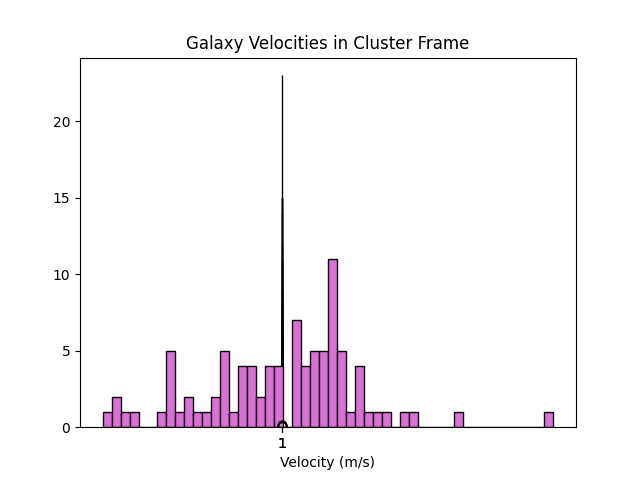

In [39]:
plt.hist(filtered_df['velocity'], bins=50, color='orchid', edgecolor='black')
plt.title("Galaxy Velocities in Cluster Frame")
plt.xlabel("Velocity (m/s)")
plt.grid()
plt.show()


In [40]:
disp = filtered_df['velocity'].std()
print(f"Velocity Dispersion: {disp:.2f} m/s")


Velocity Dispersion: 1218583.41 m/s


In [41]:
H_0 = 67.7 * 1000 / (3.086e22)  # in s⁻¹
q0 = -0.534
z = z_bar

r = (c.value / H_0) * (z - (1 + q0) * z**2 / 2)  # comoving distance in meters
ra = r / (1 + z)  # angular diameter distance in meters

theta_rad = (filtered_df['proj_sep'].mean() * u.arcmin).to(u.rad).value
diameter = ra * theta_rad  # in meters

print(f"Estimated Diameter: {diameter:.2e} meters")

Estimated Diameter: 1.76e+22 meters


In [42]:
M_dyn = 3 * (disp**2) * (diameter / 2) / G.value  # in kg
M_dyn /= 2e30  # convert to solar masses

print(f"Dynamical Mass of the Cluster: {M_dyn:.2e} solar masses")


Dynamical Mass of the Cluster: 2.93e+14 solar masses


In [43]:
D_L = cosmo.luminosity_distance(z_bar)  # at cluster redshift
mu = 5 * np.log10(D_L.value) + 25

In [44]:
r_mags = filtered_df['rmag'].dropna()

In [45]:
M_r = r_mags - mu

In [47]:
M_sun_r = 4.65
L_r = 10 ** ((M_sun_r - M_r) / 2.5)

In [48]:
L_total = L_r.sum()  # in solar units

# Assume mass-to-light ratio for clusters
ML_ratio = 100
M_luminous = L_total * ML_ratio

print(f"Total r-band Luminosity: {L_total:.2e} L☉")
print(f"Luminous Mass Estimate: {M_luminous:.2e} M☉")


Total r-band Luminosity: 2.31e+12 L☉
Luminous Mass Estimate: 2.31e+14 M☉


In [49]:
mass_ratio = M_dyn / M_luminous
print(f"Mass Ratio (Dynamical / Luminous): {mass_ratio:.2f}")

Mass Ratio (Dynamical / Luminous): 1.27
